In [14]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('../data/Loan_default.csv')
df.head()

,,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [15]:
def calculate_leverage(row):
    ratio = row['LoanAmount'] / row['Income']
    
    if ratio < 1.0:
        return 'Low Leverage (<1x Income)'
    elif ratio <= 2.5:
        return 'Medium Leverage (1x-2.5x)'
    else:
        return 'High Leverage (>2.5x Income)'

df['LeverageCategory'] = df.apply(calculate_leverage, axis=1)

print(df['LeverageCategory'].value_counts())

LeverageCategory
Medium Leverage (1x-2.5x)       104755
Low Leverage (<1x Income)        80675
High Leverage (>2.5x Income)     69917
Name: count, dtype: int64


In [16]:
risk_matrix = pd.crosstab(
    index=df['EmploymentType'], 
    columns=df['LeverageCategory'], 
    values=df['Default'], 
    aggfunc='mean'
) * 100

risk_matrix.round(2)

LeverageCategory,High Leverage (>2.5x Income),Low Leverage (<1x Income),Medium Leverage (1x-2.5x)
EmploymentType,,,
Full-time,14.99,6.33,8.23
Part-time,18.63,8.38,10.29
Self-employed,17.37,8.24,10.01
Unemployed,21.06,9.78,11.37


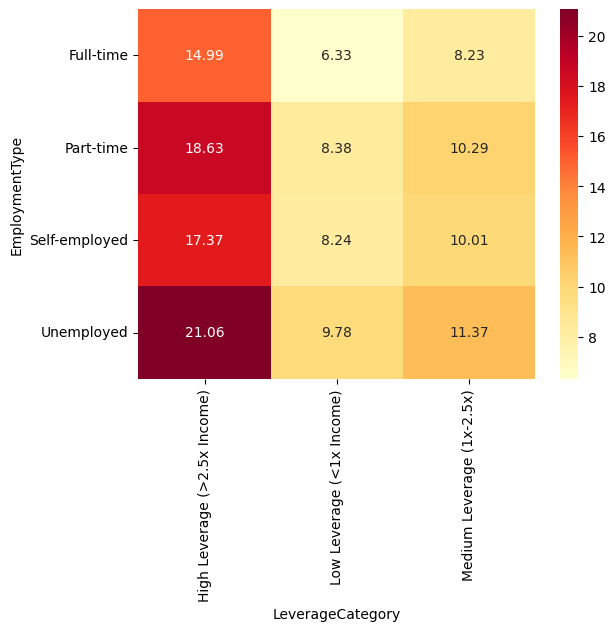

<Figure size 800x600 with 0 Axes>

In [19]:
sns.heatmap(risk_matrix, annot=True, cmap='YlOrRd', fmt='.2f')
plt.figure(figsize=(8,6))
plt.show()

In [22]:
three_factor_risk = df.groupby(['EmploymentType', 'LeverageCategory', 'HasCoSigner'])['Default'].mean() * 100
three_factor_risk = three_factor_risk.reset_index()
three_factor_risk.round(2)

,EmploymentType,LeverageCategory,HasCoSigner,Default
0,Full-time,High Leverage (>2.5x Income),No,16.58
1,Full-time,High Leverage (>2.5x Income),Yes,13.43
2,Full-time,Low Leverage (<1x Income),No,7.02
3,Full-time,Low Leverage (<1x Income),Yes,5.64
4,Full-time,Medium Leverage (1x-2.5x),No,9.12
5,Full-time,Medium Leverage (1x-2.5x),Yes,7.34
6,Part-time,High Leverage (>2.5x Income),No,20.42
7,Part-time,High Leverage (>2.5x Income),Yes,16.86
8,Part-time,Low Leverage (<1x Income),No,9.39
9,Part-time,Low Leverage (<1x Income),Yes,7.36


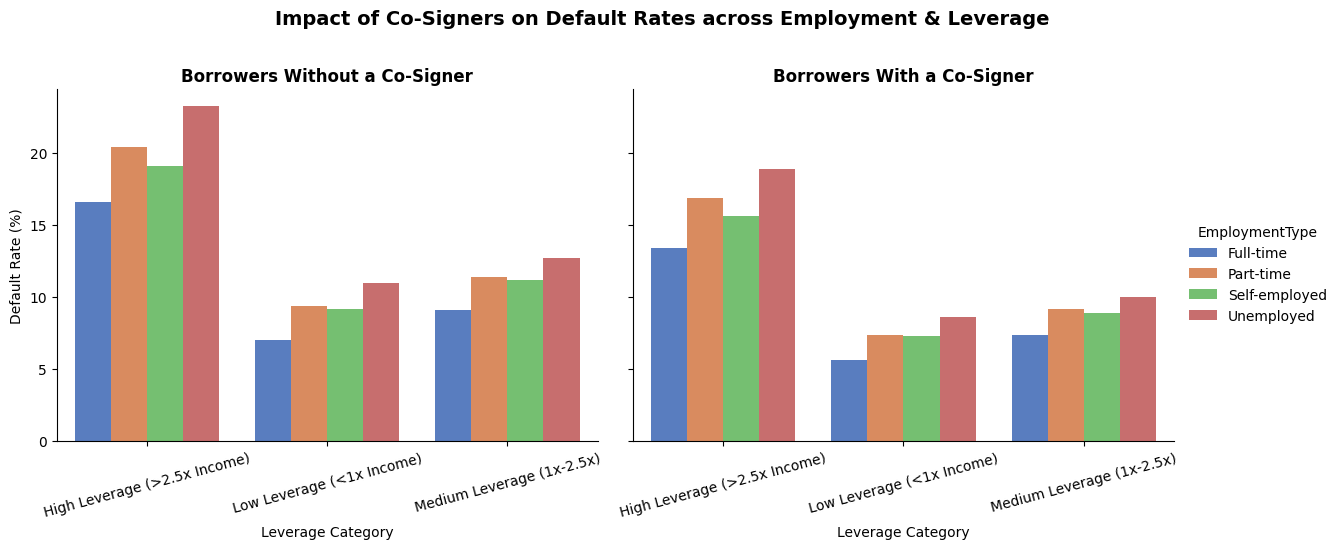

In [ ]:
g = sns.catplot(data=three_factor_risk,x='LeverageCategory',y='Default',hue='EmploymentType',col='HasCoSigner',
                kind='bar',height=5,aspect=1.2,palette='muted')
g.set_axis_labels("Leverage Category", "Default Rate (%)")
g.set_xticklabels(rotation=15) 

axes = g.axes.flatten()
axes[0].set_title("Borrowers Without a Co-Signer", fontsize=12, fontweight='bold')
axes[1].set_title("Borrowers With a Co-Signer", fontsize=12, fontweight='bold')

plt.subplots_adjust(top=0.82)
g.figure.suptitle("Impact of Co-Signers on Default Rates across Employment & Leverage", fontsize=14, fontweight='bold')

plt.show()

In [24]:
policy_filter = (df['EmploymentType'] == 'Unemployed') & (df['LeverageCategory'] == 'High Leverage (>2.5x Income)')
blocked_loans = df[policy_filter]
total_blocked = blocked_loans.shape[0]
defaults_avoided = blocked_loans['Default'].sum()
capital_saved = blocked_loans[blocked_loans['Default'] == 1]['LoanAmount'].sum()

print(f"Total Applications Blocked: {total_blocked:,}")
print(f"Actual Defaults Avoided:    {defaults_avoided:,}")
print(f"Total Capital Saved:        ${capital_saved:,.2f}")

Total Applications Blocked: 17,650
Actual Defaults Avoided:    3,717
Total Capital Saved:        $683,048,393.00


In [ ]:
wrongly_blocked = blocked_loans[blocked_loans['Default'] == 0]
estimated_interest_rate = 0.10
revenue_lost = (wrongly_blocked['LoanAmount'] * estimated_interest_rate).sum()
net_savings = capital_saved - revenue_lost
print("=== POLICY EFFICIENCY METRICS ===")
print(f"Capital Saved from Defaults:   ${capital_saved:,.2f}")
print(f"Interest Revenue Sacrificed:   ${revenue_lost:,.2f}")
print(f"--------------------------------------------------")
print(f"NET FINANCIAL IMPACT TO BANK:  ${net_savings:,.2f}")

=== POLICY EFFICIENCY METRICS ===
Capital Saved from Defaults:   $683,048,393.00
Interest Revenue Sacrificed:   $248,828,509.40
--------------------------------------------------
NET FINANCIAL IMPACT TO BANK:  $434,219,883.60


In [26]:
df.to_csv("cleaned_credit_risk_data.csv", index=False)